# COMP662 - Tutorial 5
# Synthetic Land-Use Dataset Generation

Lincoln University, Department of Computing.

Generative AI course. This tutorial goes with the *Synthetic Land-Use Dataset Generation* lecture.

---

### What you will learn
By the end of this tutorial you should be able to:
1. Explain why we need synthetic data (the data bottleneck).
2. Tell the difference between data augmentation and synthetic data generation.
3. Generate synthetic tabular land-use data four ways: with SMOTE (a simple statistical oversampler), and with three generative models written in PyTorch, a Variational Autoencoder (VAE), a GAN, and a diffusion model.
4. Build a **conditional VAE** that generates any one of several classes from a single trained model, by feeding the class label in alongside the data.
5. Judge and compare synthetic data on fidelity, diversity, and utility.
6. Recognise the main risks: bias, mode collapse, hallucination, and privacy.

### How this tutorial is structured
Part 1 is a guided exercise (about 1.5 hours): you read, run, and follow along with the code.
Part 2 is a shorter exercise (about 30 minutes) that you work through on your own.

Every code line has a comment next to it. If you are new to this, read those comments as you go; they explain what each line does.

---
## Section 0 - Setup: running on Kaggle or Colab (free GPUs)

You do not need a powerful computer for this. The whole tutorial runs in a few seconds on an ordinary CPU.
You will not need a GPU here, but it is worth learning how to turn one on, since the later tutorials on images and diffusion will need it.

### Option A: Kaggle Notebooks (free, what we recommend)
1. Go to <https://www.kaggle.com> and make a free account.
2. Click **Create → New Notebook**.
3. On the right panel: **Settings → Accelerator → GPU T4 x2** (or GPU P100).
4. **Settings → Internet → On** (only needed if you download data; here we generate our own, so internet is optional).
5. Upload this `.ipynb` via **File → Import Notebook**, or copy cells across.

### Option B: Google Colab (free)
1. Go to <https://colab.research.google.com>.
2. **File → Upload notebook** and pick this file.
3. Turn on GPU: **Runtime → Change runtime type → Hardware accelerator → T4 GPU → Save**.

Either one gives you a free cloud GPU, so everyone in the class works in the same environment and there is nothing to install on your own machine.

The next cell checks what hardware you ended up with.

In [23]:
# Check what hardware is available and pick the best "device" automatically.
import torch                                  # PyTorch: our deep-learning library

# Try accelerators in order of preference, then fall back to CPU:
#   1. CUDA  -> NVIDIA GPUs. This also covers Kaggle and Colab GPUs (they are CUDA).
#   2. MPS   -> Apple Silicon GPUs (M1/M2/M3 Macs) via Apple's Metal backend.
#   3. CPU   -> always works, and is plenty for this small tutorial.
if torch.cuda.is_available():                  # NVIDIA / Kaggle / Colab GPU present?
    device = "cuda"                            # use the CUDA GPU
elif torch.backends.mps.is_available():        # Apple Silicon GPU present? (Mac)
    device = "mps"                             # use the Metal (MPS) GPU
else:                                           # nothing special found
    device = "cpu"                             # fall back to the processor

print("PyTorch version :", torch.__version__) # show the installed PyTorch version
print("Using device    :", device)            # 'cuda' / 'mps' = GPU, 'cpu' = processor
if device == "cuda":                           # CUDA GPU: we can ask for its name
    print("GPU name        :", torch.cuda.get_device_name(0))  # e.g. 'Tesla T4'
elif device == "mps":                           # Apple GPU: no name API, just confirm
    print("GPU             : Apple Silicon (MPS) GPU")
else:
    print("No GPU found, using CPU. That is fine; this tutorial is tiny and fast on CPU.")

PyTorch version : 2.8.0
Using device    : mps
GPU             : Apple Silicon (MPS) GPU


In [24]:
# Install any missing packages. On Kaggle/Colab these are usually already there.
# The leading '!' runs a shell command from inside the notebook.
# (Uncomment the next line ONLY if an import below fails.)
# !pip -q install torch scikit-learn imbalanced-learn plotly pandas matplotlib
print("If all imports in the next cell work, you do not need to run the pip line above.")

If all imports in the next cell work, you do not need to run the pip line above.


In [25]:
# Core imports used across the whole tutorial. Run this once.
import numpy as np                 # numerical arrays and math
import pandas as pd                # tables (DataFrames) - perfect for tabular land-use data
import matplotlib.pyplot as plt    # 2D plotting (always works, even offline)

# Make results reproducible: the same "random" numbers every run.
SEED = 42                          # any fixed integer works
np.random.seed(SEED)               # seed NumPy's random generator
torch.manual_seed(SEED)            # seed PyTorch's random generator

# Try to import Plotly for nice INTERACTIVE 3D plots. If it is missing,
# we set HAVE_PLOTLY = False and fall back to static matplotlib later.
try:
    import plotly.express as px            # high-level interactive plots
    import plotly.graph_objects as go      # lower-level interactive plots
    HAVE_PLOTLY = True                      # flag: interactive plots available
    print("Plotly available - you will get interactive 3D plots.")
except Exception:                          # any import error -> no plotly
    HAVE_PLOTLY = False                     # flag: fall back to matplotlib
    print("Plotly not available - we will use static 2D/3D matplotlib instead.")

Plotly available - you will get interactive 3D plots.


---
# PART 1 - Guided Exercise (~1.5 hours)
Run each cell in order, read the comments, and look at the plots before moving on.

## Section 1 - Why do we need synthetic data?

Real land-use projects (farms, soil, crops, buildings) often run into a data bottleneck. A few common cases:

| Problem (from the lecture) | A concrete example |
|---|---|
| Expensive labeling | An expert agronomist has to hand-label every diseased plant photo. |
| Rare event scarcity | A new crop disease has only shown up a handful of times. |
| Imbalanced classes | 20,000 healthy plants but only 500 diseased ones. |
| Privacy concerns | Farmers do not want their exact field yields made public. |
| Missing data | A weather sensor was broken for two weeks. |

There are two broad ways to get more data out of what you have.

The first is data augmentation: you take existing data and modify it (rotate, flip, add noise). This produces variations of what you already have, not genuinely new information, but it is cheap and low-risk.

The second is synthetic data: you generate new samples that follow the same statistical patterns as the real data. This can create rare events and fill in gaps that augmentation cannot.

One warning before we start. More data is not automatically better. Noisy, mislabeled, or low-quality data can make a model worse, so we will spend Section 7 checking whether our synthetic data is any good.

In [26]:
# A 30-second demo of the DIFFERENCE between augmentation and synthesis,
# on a single number (say, a field's rainfall reading of 800 mm).

real_value = 800.0                                  # one real measurement (mm of rain)

# --- AUGMENTATION: tweak the existing value (add small noise) -------------
# We just jitter the real number; it stays "anchored" to the original.
augmented = real_value + np.random.normal(0, 20, size=5)  # 5 noisy copies (std=20mm)

# --- SYNTHESIS: learn the distribution, then sample fresh values ----------
# Pretend we learned rainfall ~ Normal(mean=750, std=120) from many fields.
synthetic = np.random.normal(750, 120, size=5)      # 5 brand-new samples from that model

print("Original value :", real_value)
print("Augmented (jittered copies) :", np.round(augmented, 1))
print("Synthetic (new samples)     :", np.round(synthetic, 1))
print("\nAugmentation stays near 800; synthesis can land anywhere the model allows.")

Original value : 800.0
Augmented (jittered copies) : [809.9 797.2 813.  830.5 795.3]
Synthetic (new samples)     : [721.9 939.5 842.1 693.7 815.1]

Augmentation stays near 800; synthesis can land anywhere the model allows.


## Section 2 - Our land-use dataset: farm parcels

The lecture lists several kinds of land-use data. We will work with the simplest one, a plain table of farm-management records, since it is the easiest to reason about while learning.

Rather than download anything, we build a small farm-parcel table ourselves. Each row is one land parcel, with these columns:

| Column | Meaning |
|---|---|
| `soil_ph` | soil acidity (around 5.5 to 7.5) |
| `rainfall_mm` | yearly rainfall |
| `temp_c` | average temperature |
| `area_ha` | parcel size in hectares |
| `elevation_m` | height above sea level |
| `health` | label: `0 = healthy`, `1 = diseased crop` (the rare class) |

Generating the data ourselves has a few practical advantages: there is nothing to download, the table is clean, and because we wrote the rules behind it, we can later check whether our synthetic data actually reproduced those rules.

We make the diseased class deliberately rare so the setup matches the lecture's case study on rare crop-disease detection.

In [27]:
# Build the base farm-parcel dataset. Think of THIS as our "real" collected data.
N_HEALTHY  = 1900          # many healthy parcels (the common, easy class)
N_DISEASED = 100           # few diseased parcels  -> deliberate CLASS IMBALANCE (~5%)

def make_parcels(n, diseased):
    # Generate `n` parcels. `diseased` is False for healthy rows, True for diseased.
    # Diseased crops tend to sit in more acidic, wetter, warmer, lower fields.
    ph    = np.random.normal(6.0 if diseased else 6.7, 0.4, n)   # soil pH
    rain  = np.random.normal(1100 if diseased else 850, 150, n)  # rainfall (mm)
    temp  = np.random.normal(19.0 if diseased else 16.5, 1.5, n) # temperature (C)
    area  = np.random.normal(12.0, 4.0, n)                       # parcel area (ha) - same for both
    elev  = np.random.normal(120 if diseased else 200, 50, n)    # elevation (m)
    label = np.ones(n, int) if diseased else np.zeros(n, int)    # 1=diseased, 0=healthy
    # Stack the 5 features column-wise and return features + labels.
    X = np.column_stack([ph, rain, temp, area, elev])            # shape (n, 5)
    return X, label

# Make both groups, then stack them into one dataset.
Xh, yh = make_parcels(N_HEALTHY,  diseased=False)  # healthy parcels
Xd, yd = make_parcels(N_DISEASED, diseased=True)   # diseased parcels
X = np.vstack([Xh, Xd])                             # all features  (2000, 5)
y = np.concatenate([yh, yd])                        # all labels    (2000,)

# Put it in a pandas DataFrame so it is easy to read and plot.
FEATURES = ["soil_ph", "rainfall_mm", "temp_c", "area_ha", "elevation_m"]  # column names
df = pd.DataFrame(X, columns=FEATURES)             # features as a table
df["health"] = y                                   # add the label column
df.head()                                          # show the first 5 rows

,soil_ph,rainfall_mm,temp_c,area_ha,elevation_m,health
0,6.514633,1109.877250,15.009206,12.348066,211.772790,0
1,6.513708,1184.695022,17.130287,7.855426,15.581735,0
2,6.796785,945.707665,15.215253,15.426950,159.617472,0
3,5.934688,925.126671,16.646506,13.592193,180.421501,0
4,6.010033,579.841340,14.603252,13.578320,275.253102,0


In [28]:
# Quick sanity check: how imbalanced is the dataset?
counts = df["health"].value_counts().sort_index()     # count rows per class
print("Healthy (0):", counts[0])                       # common class
print("Diseased(1):", counts[1])                       # rare class
print(f"Diseased share: {counts[1]/len(df)*100:.1f}%") # percentage of the rare class

Healthy (0): 1900
Diseased(1): 100
Diseased share: 5.0%


## Section 3 - Look at the data first

It is always worth looking at data before modelling it. Here we plot how many parcels fall in each class, and where the two classes sit relative to each other. This is the class-imbalance problem made visible.

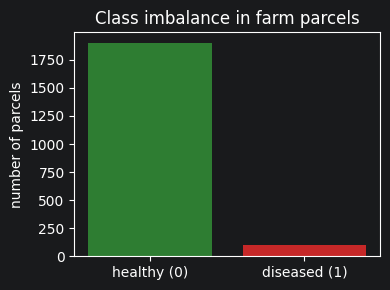

In [29]:
# Bar chart of class balance - the imbalance should be obvious.
plt.figure(figsize=(4,3))                                  # small figure
plt.bar(["healthy (0)", "diseased (1)"],                   # x labels
        [counts[0], counts[1]],                            # bar heights
        color=["#2e7d32", "#c62828"])                      # green / red
plt.ylabel("number of parcels")                            # y axis label
plt.title("Class imbalance in farm parcels")               # title
plt.tight_layout(); plt.show()                             # render

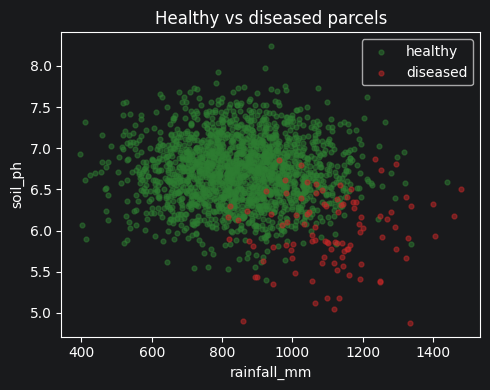

In [30]:
# Scatter: rainfall vs soil_ph, coloured by class.
# This shows the two classes overlap but are NOT identical - a model can learn the difference.
plt.figure(figsize=(5,4))                                              # figure
for label, colour, name in [(0,"#2e7d32","healthy"),(1,"#c62828","diseased")]:
    m = df["health"] == label                                          # mask: rows of this class
    plt.scatter(df.loc[m,"rainfall_mm"], df.loc[m,"soil_ph"],          # x=rain, y=pH
                s=12, alpha=0.5, c=colour, label=name)                 # small semi-transparent dots
plt.xlabel("rainfall_mm"); plt.ylabel("soil_ph")                       # axis labels
plt.legend(); plt.title("Healthy vs diseased parcels")                 # legend + title
plt.tight_layout(); plt.show()                                         # render

In [31]:
# INTERACTIVE 3D scatter (slide-friendly). Falls back to static 3D if Plotly is missing.
# 3D view: rainfall x soil_ph x temperature, coloured by class.
if HAVE_PLOTLY:                                                        # interactive path
    fig = px.scatter_3d(df, x="rainfall_mm", y="soil_ph", z="temp_c", # 3 axes
                        color=df["health"].map({0:"healthy",1:"diseased"}),  # colour by class name
                        opacity=0.6, height=500,                      # see-through points
                        title="3D view of parcels (drag to rotate)")
    fig.update_traces(marker_size=3)                                  # smaller markers
    fig.show()                                                        # interactive render
else:                                                                  # static fallback
    from mpl_toolkits.mplot3d import Axes3D                           # enables 3D in matplotlib
    fig = plt.figure(figsize=(6,5)); ax = fig.add_subplot(111, projection="3d")
    for label, colour in [(0,"#2e7d32"),(1,"#c62828")]:              # per class
        m = df["health"] == label                                    # mask
        ax.scatter(df.loc[m,"rainfall_mm"], df.loc[m,"soil_ph"], df.loc[m,"temp_c"],
                   s=8, alpha=0.5, c=colour)                          # plot 3D points
    ax.set_xlabel("rainfall"); ax.set_ylabel("soil_ph"); ax.set_zlabel("temp_c")
    plt.title("3D view of parcels (static)"); plt.show()

## Section 4 - A baseline: SMOTE

Before reaching for deep learning, it helps to have a simple baseline. SMOTE (Synthetic Minority Over-sampling Technique) is about as simple as synthetic data gets.

The idea is this: to make a new diseased parcel, take a real diseased parcel, find one of its nearest diseased neighbours, and place a new point somewhere on the line between the two.

It is fast and needs no training, which makes it a good reference point. Its weakness is that it only interpolates between points that already exist, so it does not add much variety and can occasionally place points in unrealistic spots. We will hold our VAE up against it later.

In [32]:
# !pip install imbalanced-learn

In [33]:
# Use imbalanced-learn's SMOTE to balance the classes by creating synthetic diseased parcels.
from imblearn.over_sampling import SMOTE     # SMOTE implementation

sm = SMOTE(random_state=SEED)                # create the oversampler (reproducible)
# fit_resample learns from X,y and returns a NEW balanced set with extra synthetic minority rows.
X_smote, y_smote = sm.fit_resample(X, y)     # X_smote has many new diseased rows

print("Before SMOTE:", np.bincount(y))       # [healthy, diseased] counts before
print("After  SMOTE:", np.bincount(y_smote)) # now both classes are equal

ModuleNotFoundError: No module named 'imblearn'

In [ ]:
# Visualise what SMOTE created. Original diseased = dark red, SMOTE-made diseased = orange.
smote_only = X_smote[len(X):]                          # rows AFTER the originals = pure synthetic

plt.figure(figsize=(5,4))                              # figure
plt.scatter(X[y==0,1], X[y==0,0], s=10, alpha=0.2, c="#2e7d32", label="healthy (real)")  # rain,ph
plt.scatter(X[y==1,1], X[y==1,0], s=25, c="#c62828", label="diseased (real)")            # real minority
plt.scatter(smote_only[:,1], smote_only[:,0], s=12, alpha=0.5, c="#ff9800",              # synthetic
            label="diseased (SMOTE)")
plt.xlabel("rainfall_mm"); plt.ylabel("soil_ph"); plt.legend()
plt.title("SMOTE fills in between real diseased points")
plt.tight_layout(); plt.show()

## Section 5 - A generative model: the VAE

SMOTE only interpolates between points it already has. A Variational Autoencoder (VAE) goes further: it learns the underlying distribution of the data, and once it has, it can sample genuinely new points from it. The lecture describes this as a "smooth latent representation".

### The idea behind a VAE
A VAE is made of two small neural networks. The encoder takes a parcel (5 numbers) and squeezes it down to a tiny latent code `z` (here just 2 numbers). It does not output a single point but a small cloud, described by a mean `mu` and a spread `sigma`. The decoder does the reverse: it takes a latent code `z` and rebuilds the 5 parcel numbers.

To generate new data once the VAE is trained, we draw a random `z` from a standard normal and pass it through the decoder.

### Why the loss has two parts
Training balances two goals. The reconstruction loss pushes the rebuilt parcel to match the input, which is what gives us fidelity. The KL term keeps the latent clouds close to a standard normal, which keeps the latent space smooth enough that we can sample from it safely. We come back to what happens when this balance goes wrong.

One preparatory step first: we scale the features, because neural networks train more reliably when their inputs are on a similar scale.

In [ ]:
# Scale features to mean 0, std 1. VAEs (and most nets) train much better on scaled inputs.
from sklearn.preprocessing import StandardScaler   # standardises columns

scaler = StandardScaler()                           # create the scaler
# We train the VAE to generate the RARE class, so fit only on diseased parcels.
X_diseased = X[y == 1]                              # real diseased feature rows
X_scaled = scaler.fit_transform(X_diseased)         # learn mean/std and transform

# Convert the NumPy array to a PyTorch tensor on our chosen device (CPU/GPU).
X_tensor = torch.tensor(X_scaled, dtype=torch.float32, device=device)
print("Training tensor shape:", X_tensor.shape)     # (num_diseased, 5)

In [ ]:
import torch.nn as nn   # neural-network building blocks (layers, activations)

# Define the VAE as a small PyTorch module. Tiny on purpose -> trains in seconds.
class VAE(nn.Module):
    # NOTE: `hidden=32` is the WIDTH (neurons per layer), NOT the number of layers.
    # This model is still small: 2 hidden layers in the encoder, 2 in the decoder.
    def __init__(self, n_features=5, hidden=32, latent=2):
        super().__init__()                              # set up nn.Module internals
        # ----- ENCODER: features -> hidden -> hidden -> (mu, logvar) -----
        # Two hidden layers (each 32 neurons wide) - enough capacity, still cheap to train.
        self.enc = nn.Sequential(                       # a stack of layers
            nn.Linear(n_features, hidden),              # layer 1: 5 -> 32
            nn.ReLU(),                                  # non-linearity
            nn.Linear(hidden, hidden),                  # layer 2: 32 -> 32
            nn.ReLU(),                                  # non-linearity
        )
        self.fc_mu     = nn.Linear(hidden, latent)      # hidden -> mean of latent cloud
        self.fc_logvar = nn.Linear(hidden, latent)      # hidden -> log-variance of cloud
        # ----- DECODER: latent -> hidden -> hidden -> features -----
        self.dec = nn.Sequential(                       # rebuild the parcel
            nn.Linear(latent, hidden),                  # layer 1: 2 -> 32
            nn.ReLU(),                                   # non-linearity
            nn.Linear(hidden, hidden),                  # layer 2: 32 -> 32
            nn.ReLU(),                                   # non-linearity
            nn.Linear(hidden, n_features),              # output:  32 -> 5 (reconstructed features)
        )

    def encode(self, x):
        h = self.enc(x)                                 # run encoder body
        return self.fc_mu(h), self.fc_logvar(h)         # output mean and log-variance

    def reparameterize(self, mu, logvar):
        # "Reparameterization trick": sample z = mu + sigma * eps, so we can backprop.
        std = torch.exp(0.5 * logvar)                   # convert log-variance -> std dev
        eps = torch.randn_like(std)                     # random noise, same shape as std
        return mu + eps * std                           # a sampled latent code z

    def decode(self, z):
        return self.dec(z)                              # rebuild features from z

    def forward(self, x):
        mu, logvar = self.encode(x)                     # encode input -> cloud params
        z = self.reparameterize(mu, logvar)            # sample a latent code
        return self.decode(z), mu, logvar              # reconstruction + cloud params

model = VAE().to(device)                                # build the model on CPU/GPU
print(model)                                            # show the architecture

### The one tricky part: the reparameterization trick

The encoder gives us a cloud (`mu`, `sigma`), and we need to draw a random sample `z` from it. The problem is that a plain random draw has no gradient, so the network cannot learn through it and training would stall.

The trick is to rewrite the draw as:

```
z = mu + sigma * eps        where eps ~ Normal(0, 1)
```

Now the randomness sits entirely in `eps`, which is just a noise input, while `mu` and `sigma` are ordinary network outputs. Gradients can flow through `mu` and `sigma`, so the network still learns, and `z` is still random. That is all the `reparameterize()` method above is doing: it moves the randomness off to the side so back-propagation keeps working.

In [ ]:
# The VAE loss = reconstruction error + KL divergence.
def vae_loss(recon, x, mu, logvar, beta=1.0):
    # Reconstruction: how far the rebuilt parcel is from the real one (mean squared error).
    recon_loss = nn.functional.mse_loss(recon, x, reduction="mean")
    # KL divergence: pulls each latent cloud toward a standard normal (smooth latent space).
    # Closed-form KL for Gaussian vs standard normal, averaged over the batch.
    kl = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    # beta lets us weight the KL term (beta=1 is the standard VAE).
    return recon_loss + beta * kl, recon_loss, kl

### What the two loss terms actually do

The VAE is pulled in two directions at once, and the loss balances them.

The reconstruction loss (mean squared error) measures the gap between the input parcel and what the decoder rebuilds. Driving it down means the VAE is copying the real data accurately, which is the fidelity we want.

The KL divergence is a measure of how different two distributions are. Here it tracks how far each latent cloud (`mu`, `sigma`) drifts from a plain standard normal. Pulling the clouds back toward `Normal(0,1)` packs them around the origin without gaps, so that when we later sample `z = randn(...)` we land in regions the decoder knows how to handle.

Both terms are needed. With reconstruction alone, the encoder could scatter codes anywhere, and sampling would produce nonsense. With KL alone, every parcel would collapse to the same point. Roughly: reconstruction keeps the output realistic, and KL keeps the latent space something we can sample from.

### A short glossary for the training loop

If deep learning is new to you, here are the terms that come up in the loop below.

| Term | What it means |
|---|---|
| epoch | one full pass over the training data. We do 600 of them. |
| forward pass | push data through the network to get an output (`model(X_tensor)`). |
| loss | a single number saying how wrong the output is. We want it small. |
| gradient | the slope of the loss, telling us which way to nudge each weight to reduce it. |
| back-propagation (`loss.backward()`) | computes those gradients automatically. |
| optimizer (`Adam`) | the rule that updates the weights using the gradients. |
| learning rate (`lr`) | the step size. Too large is unstable, too small is slow; `0.005` works well here. |
| `zero_grad()` | clears the previous step's gradients so they do not pile up. |
| ReLU | the activation `max(0, x)`, which lets the network learn curves rather than just straight lines. |

The loop is the same five steps every time: zero the gradients, forward pass, compute the loss, back-propagate, update the weights.

In [ ]:
# Train the VAE. Small data + tiny model => this finishes in a couple of seconds.
optimizer = torch.optim.Adam(model.parameters(), lr=5e-3)   # Adam optimiser, learning rate 0.005
EPOCHS = 600                                                 # passes over the data
BETA   = 0.15                                                # KL weight (see note after the curve)

history = {"total": [], "recon": [], "kl": []}              # store losses for plotting

model.train()                                               # set model to training mode
for epoch in range(EPOCHS):                                 # loop over epochs
    optimizer.zero_grad()                                  # clear old gradients
    recon, mu, logvar = model(X_tensor)                    # forward pass on all diseased rows
    loss, rl, kl = vae_loss(recon, X_tensor, mu, logvar, beta=BETA)  # 3 loss pieces, KL weighted by BETA
    loss.backward()                                        # backpropagate: compute gradients
    optimizer.step()                                       # update the weights
    # Record the losses (as plain Python floats) for the curves below.
    history["total"].append(loss.item())                  # total loss
    history["recon"].append(rl.item())                    # reconstruction part
    history["kl"].append(kl.item())                       # KL part
    if (epoch+1) % 50 == 0:                                 # print every 50 epochs
        print(f"epoch {epoch+1:3d}  total={loss.item():.3f}  recon={rl.item():.3f}  kl={kl.item():.3f}")

print("Training done.")

### Watching the loss

The two pieces behave differently. Reconstruction should fall as the decoder gets better at rebuilding parcels, which is fidelity improving. The KL term meanwhile keeps the latent space tidy enough to sample from.

In [ ]:
# Plot the training curves (2D, always works).
plt.figure(figsize=(6,4))                                  # figure
plt.plot(history["total"], label="total loss")             # total
plt.plot(history["recon"], label="reconstruction")         # recon part
plt.plot(history["kl"],    label="KL term")                # kl part
plt.xlabel("epoch"); plt.ylabel("loss"); plt.legend()
plt.title("VAE training losses")
plt.tight_layout(); plt.show()

### When the loss stays flat

This is a common VAE problem and worth understanding. If the reconstruction loss sits flat near the data variance (around 1.0 on standardised data) while the KL term sits near zero, you have run into posterior collapse: the decoder is ignoring the latent code and just outputting the average parcel.

The natural reaction is to add more layers, but that is usually not the cause. We tried it:

| Model | reconstruction loss |
|---|---|
| 1 hidden layer, `beta=1` | ~0.97 (flat, collapsed) |
| 2 hidden layers, `beta=1` | ~1.00 (collapsed even harder, KL near 0) |
| 1 hidden layer, `beta=0.1` | ~0.37 (now learning) |
| 2 hidden layers, `beta=0.1` | ~0.17 (best) |

Adding layers while keeping `beta=1` actually made things worse. The real cause is the KL term overpowering a small dataset: it forces every latent cloud onto the prior and leaves the decoder nothing to work with.

The fix is `beta`, the weight on the KL term in `vae_loss` (this is what makes it a beta-VAE). Lowering it, we use `BETA=0.15`, lets the latent code carry information again, and the reconstruction loss starts to drop. A little extra capacity (two hidden layers of 32 neurons on each side) and more epochs then tidy it up. To be clear, 32 is the width of each layer, not the number of layers; this is still a small model with two hidden layers per side.

So the order to try things in is: lower `beta` first, then train longer or lower the learning rate, and only add capacity after that. Going too far the other way (say `beta=0.001`) is its own problem: reconstruction looks great, but the latent space drifts from the prior and sampling new data gets worse. `beta` is a dial to balance, not to maximise.

In [ ]:
# INTERACTIVE 3D loss surface: epoch vs reconstruction vs KL, height = total loss.
# This gives a nice "descent into a valley" view of training. Falls back to 2D text if no Plotly.
if HAVE_PLOTLY:                                            # interactive path
    ep = np.arange(len(history["total"]))                 # epoch index as x
    fig = go.Figure(data=[go.Scatter3d(                   # 3D line of the training path
        x=ep, y=history["recon"], z=history["kl"],        # x=epoch, y=recon, z=kl
        mode="lines+markers",                             # line with dots
        marker=dict(size=2, color=history["total"],       # colour = total loss...
                    colorscale="Viridis", showscale=True),# ...with a colour bar
        line=dict(width=3))])
    fig.update_layout(height=500, title="Training path (colour = total loss)",
                      scene=dict(xaxis_title="epoch", yaxis_title="recon loss",
                                 zaxis_title="KL term"))
    fig.show()                                            # interactive render
else:
    print("Plotly missing - see the 2D curve above instead.")  # graceful fallback

## Section 6 - Generating new parcels with the VAE

Now that the VAE is trained, generating diseased parcels is three short steps: sample latent codes `z` from a standard normal, pass them through the decoder, and undo the scaling so the numbers come back in real units (mm, degrees C, and so on).

In [ ]:
model.eval()                                              # evaluation mode (no training)
N_GEN = 1000                                              # how many synthetic parcels to make

with torch.no_grad():                                     # no gradients needed for generation
    z = torch.randn(N_GEN, 2, device=device)             # sample latent codes (latent dim = 2)
    gen_scaled = model.decode(z).cpu().numpy()           # decode -> scaled features -> NumPy

# Reverse the StandardScaler to get back real-world units.
gen = scaler.inverse_transform(gen_scaled)               # synthetic parcels in real units

# Wrap in a DataFrame for easy comparison.
df_gen = pd.DataFrame(gen, columns=FEATURES)             # synthetic diseased parcels
df_gen["health"] = 1                                      # they are all the diseased class
df_gen.head()                                             # peek at generated data

In [ ]:
# Compare real vs VAE-generated diseased parcels in the rainfall/soil_ph plane.
plt.figure(figsize=(5,4))                                                       # figure
plt.scatter(X[y==1,1], X[y==1,0], s=25, c="#c62828", label="diseased (real)")  # real
plt.scatter(df_gen["rainfall_mm"], df_gen["soil_ph"], s=10, alpha=0.4,
            c="#1565c0", label="diseased (VAE)")                                # synthetic
plt.xlabel("rainfall_mm"); plt.ylabel("soil_ph"); plt.legend()
plt.title("Real vs VAE-generated diseased parcels")
plt.tight_layout(); plt.show()

## Section 6B - A second generator: a GAN

The VAE is one generative model; the lecture also covers **GANs (Generative Adversarial Networks)**. Let us generate the same rare diseased parcels a second way and compare.

**The idea.** Two small networks compete. A **generator** turns random noise into a fake parcel (5 numbers). A **discriminator** tries to tell real diseased parcels from fake ones. Training them together pushes the generator to make parcels realistic enough to fool the discriminator.

GANs are famously tricky on small data (we only have 100 real diseased parcels). To keep it stable we add a **feature-matching** term: we nudge the generator so the mean and spread of its output match the real data. That one addition turns a wobbly GAN into a reliable one here.

In [ ]:
# Generator: random noise -> a fake 5-feature parcel (in scaled space).
class TabGenerator(nn.Module):
    def __init__(self, z_dim=8, hidden=32, n_features=5):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(z_dim, hidden), nn.ReLU(),      # noise -> hidden
            nn.Linear(hidden, hidden), nn.ReLU(),     # hidden -> hidden
            nn.Linear(hidden, n_features),            # hidden -> 5 features
        )
    def forward(self, z):
        return self.net(z)

# Discriminator: a parcel -> one score (real=high, fake=low).
class TabDiscriminator(nn.Module):
    def __init__(self, n_features=5, hidden=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_features, hidden), nn.LeakyReLU(0.2),
            nn.Linear(hidden, hidden), nn.LeakyReLU(0.2),
            nn.Linear(hidden, 1),                     # single real/fake score
        )
    def forward(self, x):
        return self.net(x)

Z_DIM = 8                                             # size of the noise vector
G = TabGenerator(Z_DIM).to(device)                    # generator
D = TabDiscriminator().to(device)                     # discriminator
opt_g = torch.optim.Adam(G.parameters(), lr=5e-4, betas=(0.5, 0.999))  # generator optimiser
opt_d = torch.optim.Adam(D.parameters(), lr=5e-4, betas=(0.5, 0.999))  # discriminator optimiser
bce = nn.BCEWithLogitsLoss()                          # real/fake loss
GAN_EPOCHS = 4000                                     # GANs need many small steps on tiny data
FM_WEIGHT = 10.0                                      # feature-matching strength (stabiliser)
BATCH_G = 64                                          # batch size
Ndis = X_tensor.shape[0]                              # number of real diseased parcels

for step in range(GAN_EPOCHS):                        # training loop
    idx = torch.randint(0, Ndis, (BATCH_G,), device=device)  # random real parcels
    real = X_tensor[idx]                              # a batch of real (scaled) parcels
    z = torch.randn(BATCH_G, Z_DIM, device=device)   # random noise
    fake = G(z)                                       # generate fakes
    # --- train discriminator: real -> 1, fake -> 0 ---
    opt_d.zero_grad()
    loss_d = bce(D(real), torch.ones(BATCH_G, 1, device=device)) + \
             bce(D(fake.detach()), torch.zeros(BATCH_G, 1, device=device))
    loss_d.backward(); opt_d.step()
    # --- train generator: fool D + match the data's mean/spread (feature matching) ---
    opt_g.zero_grad()
    fm = (fake.mean(0) - real.mean(0)).abs().mean() + (fake.std(0) - real.std(0)).abs().mean()
    loss_g = bce(D(fake), torch.ones(BATCH_G, 1, device=device)) + FM_WEIGHT * fm
    loss_g.backward(); opt_g.step()
    if (step + 1) % 800 == 0:                         # occasional print
        print(f"step {step+1:4d}  D {loss_d.item():.3f}  G {loss_g.item():.3f}")

# Generate diseased parcels with the trained GAN.
G.eval()
with torch.no_grad():
    gen_gan_scaled = G(torch.randn(N_GEN, Z_DIM, device=device)).cpu().numpy()  # scaled
gen_gan = scaler.inverse_transform(gen_gan_scaled)   # back to real units
df_gan = pd.DataFrame(gen_gan, columns=FEATURES)     # tidy DataFrame
print("GAN generated", gen_gan.shape[0], "diseased parcels")

## Section 6C - A third generator: a diffusion model

The third family from the lecture is the **diffusion model**, the engine behind today's best image and data generators. We use it to make the same diseased parcels a third way.

**The idea (two halves).**
1. **Forward:** repeatedly add a little random noise to a real parcel until it is pure noise. No learning, just a fixed noise schedule.
2. **Reverse:** train a small network to predict the noise that was added at each step. To generate, start from pure noise and let the network strip the noise away step by step, and a new parcel appears.

On this tiny tabular problem a small multi-layer network is plenty.

In [ ]:
import torch.nn.functional as F                       # functional ops (mse_loss)
T_DIFF = 100                                          # number of diffusion steps
betas = torch.linspace(1e-4, 0.02, T_DIFF, device=device)   # noise added per step
acp = torch.cumprod(1 - betas, 0)                     # cumulative kept fraction

def tab_time_embed(t, dim=16):
    # Turn an integer timestep into a smooth vector (tells the net the noise level).
    half = dim // 2
    freqs = torch.exp(torch.arange(half, device=device) * -(np.log(10000) / (half - 1)))
    a = t[:, None].float() * freqs[None]
    return torch.cat([a.sin(), a.cos()], 1)

class TabDenoiser(nn.Module):
    # Predicts the noise in a parcel, given the parcel and the timestep.
    def __init__(self, n_features=5, hidden=64, tdim=16):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_features + tdim, hidden), nn.ReLU(),  # parcel + time -> hidden
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, n_features),                    # -> predicted noise (5)
        )
    def forward(self, x, t):
        return self.net(torch.cat([x, tab_time_embed(t)], 1))

denoiser = TabDenoiser().to(device)                   # build the denoiser
opt = torch.optim.Adam(denoiser.parameters(), lr=2e-3)  # optimiser
DIFF_EPOCHS = 3000                                    # training steps
for step in range(DIFF_EPOCHS):                       # training loop
    idx = torch.randint(0, Ndis, (BATCH_G,), device=device)  # random real parcels
    x0 = X_tensor[idx]                                # clean (scaled) parcels
    t = torch.randint(0, T_DIFF, (BATCH_G,), device=device)  # random timestep each
    a = acp[t][:, None]                               # kept fraction at that step
    noise = torch.randn_like(x0)                      # the noise we add
    xt = a.sqrt() * x0 + (1 - a).sqrt() * noise       # noised parcel (forward step)
    loss = F.mse_loss(denoiser(xt, t), noise)         # predict the noise
    opt.zero_grad(); loss.backward(); opt.step()      # update
    if (step + 1) % 600 == 0:                         # occasional print
        print(f"step {step+1:4d}  noise-mse {loss.item():.4f}")

# Generate diseased parcels by running the reverse process from pure noise.
denoiser.eval()
with torch.no_grad():
    x = torch.randn(N_GEN, X_tensor.shape[1], device=device)  # start from noise
    for ti in range(T_DIFF - 1, -1, -1):             # walk timesteps backwards
        tb = torch.full((N_GEN,), ti, device=device) # this timestep for all
        a = acp[ti]; b = betas[ti]; al = 1 - b        # schedule values
        eps = denoiser(x, tb)                         # predicted noise
        mean = (x - b / (1 - a).sqrt() * eps) / al.sqrt()  # one denoising step
        x = mean + b.sqrt() * torch.randn_like(x) if ti > 0 else mean  # add a little noise back
    gen_diff_scaled = x.cpu().numpy()                 # scaled samples
gen_diff = scaler.inverse_transform(gen_diff_scaled)  # back to real units
df_diff = pd.DataFrame(gen_diff, columns=FEATURES)    # tidy DataFrame
print("Diffusion generated", gen_diff.shape[0], "diseased parcels")

## Section 6D - Conditional generation: choosing which class to generate

Every generator so far was trained on **one class only** (the rare, diseased parcels), because that
is what our imbalance problem needed. But this only gets you one class per trained model. If your task
needs synthetic rows for several classes, for example three land-condition categories in an
assignment, training and keeping track of a separate generator per class gets unwieldy fast.

The fix is a **conditional** generator: give the model the class label as an extra input, alongside
the features, both when it trains and when it generates. One model then learns all classes at once,
and you choose which one to generate by choosing which label to feed in.

We extend our farm-parcel idea to a third class, **drought-stressed** (dry, hot, higher ground), so
conditioning on three classes is a real test and not just a healthy/diseased coin flip. This dataset
and model are self-contained: nothing here changes `X`, `y`, or the VAE/GAN/diffusion models above.

In [ ]:
# A third class alongside healthy (0) and diseased (1): drought-stressed (2).
def make_parcel_class(n, cls):
    # cls: 0=healthy, 1=diseased, 2=drought-stressed. Same 5 features as Section 2, one more class.
    if cls == 0:   ph, rain, temp, elev, rspread = 6.7, 850,  16.5, 200, 150   # healthy
    elif cls == 1: ph, rain, temp, elev, rspread = 6.0, 1100, 19.0, 120, 150   # diseased (wet, warm)
    else:          ph, rain, temp, elev, rspread = 6.3, 450,  22.0, 320, 90    # drought (dry, hot, high)
    X = np.column_stack([
        np.random.normal(ph, 0.4, n), np.random.normal(rain, rspread, n),
        np.random.normal(temp, 1.5, n), np.random.normal(12.0, 4.0, n),   # area, same for all classes
        np.random.normal(elev, 50, n),
    ])
    return X, np.full(n, cls)

CLASS_NAMES_3 = ["healthy", "diseased", "drought-stressed"]
N_PER_CLASS = 300                                              # balanced this time - conditioning is
Xc, yc = [], []                                                 # the point here, not imbalance
for c in range(3):
    Xi, yi = make_parcel_class(N_PER_CLASS, c)
    Xc.append(Xi); yc.append(yi)
Xc = np.vstack(Xc); yc = np.concatenate(yc)                     # (900, 5) and (900,)
print("class counts:", dict(zip(CLASS_NAMES_3, np.bincount(yc))))

scaler_c = StandardScaler()                                     # a fresh scaler for this dataset
Xc_scaled = scaler_c.fit_transform(Xc)
Xc_tensor = torch.tensor(Xc_scaled, dtype=torch.float32, device=device)
N_CLASSES = 3
Yc_onehot = F.one_hot(torch.tensor(yc, device=device), N_CLASSES).float()   # (900, 3)
print("one-hot label shape:", Yc_onehot.shape, "| example row:", Yc_onehot[0].tolist())

### A conditional VAE (CVAE)

The change from Section 5's `VAE` is small but does all the work: concatenate the one-hot class label
onto the input before the encoder, and onto the latent code before the decoder. The encoder then
learns "what does a *diseased* parcel's noise look like, on top of the class", and the decoder learns
"turn this noise back into a parcel, *of this class*". Everything else, the reparameterisation trick,
the two-part loss, is identical to Section 5.

In [ ]:
class CVAE(nn.Module):
    # Same shape as Section 5's VAE, except the class one-hot is concatenated on both sides.
    def __init__(self, n_features=5, n_classes=3, hidden=32, latent=2):
        super().__init__()
        self.encoder = nn.Sequential(nn.Linear(n_features + n_classes, hidden), nn.ReLU())
        self.mu_head = nn.Linear(hidden, latent)                 # mean of the latent cloud
        self.lv_head = nn.Linear(hidden, latent)                 # log-variance of the latent cloud
        self.decoder = nn.Sequential(nn.Linear(latent + n_classes, hidden), nn.ReLU(),
                                     nn.Linear(hidden, n_features))
    def encode(self, x, y_onehot):
        h = self.encoder(torch.cat([x, y_onehot], dim=1))        # features + label go in together
        return self.mu_head(h), self.lv_head(h)
    def decode(self, z, y_onehot):
        return self.decoder(torch.cat([z, y_onehot], dim=1))     # latent code + label go in together
    def forward(self, x, y_onehot):
        mu, logvar = self.encode(x, y_onehot)
        std = (0.5 * logvar).exp()                                # reparameterisation trick, as in
        z = mu + std * torch.randn_like(std)                      # Section 5
        return self.decode(z, y_onehot), mu, logvar

cvae = CVAE(n_features=5, n_classes=N_CLASSES, hidden=32, latent=2).to(device)
opt = torch.optim.Adam(cvae.parameters(), lr=5e-3)
BETA_C = 0.15
hist_c = []                                                       # loss per epoch
cvae.train()
for epoch in range(400):
    opt.zero_grad()
    recon, mu, logvar = cvae(Xc_tensor, Yc_onehot)                 # train on ALL THREE classes at once
    recon_loss = ((recon - Xc_tensor) ** 2).sum(1).mean()
    kl_loss = (-0.5 * (1 + logvar - mu.pow(2) - logvar.exp())).sum(1).mean()
    loss = recon_loss + BETA_C * kl_loss
    loss.backward(); opt.step()
    hist_c.append(loss.item())
    if (epoch + 1) % 100 == 0:
        print(f"epoch {epoch+1:3d}  loss={loss.item():.3f}  recon={recon_loss.item():.3f}  kl={kl_loss.item():.3f}")

plt.figure(figsize=(6, 3)); plt.plot(hist_c)                       # one loss curve, all classes together
plt.xlabel("epoch"); plt.ylabel("CVAE loss"); plt.title("training on all three classes at once")
plt.grid(True, alpha=0.3); plt.show()

### Generating a chosen class on demand

To generate, sample latent noise `z` as usual, but pick a class first and feed its one-hot label to
the decoder alongside `z`. Change only the label, and the same trained decoder produces a different
class. Nothing is retrained between the three calls below.

In [ ]:
cvae.eval()
gen_by_class = {}                                                  # keep each class's generated rows
with torch.no_grad():
    for c in range(N_CLASSES):
        z = torch.randn(300, 2, device=device)                     # fresh latent noise
        label = F.one_hot(torch.full((300,), c, device=device), N_CLASSES).float()  # THIS is the choice
        gen_scaled = cvae.decode(z, label).cpu().numpy()            # decode, conditioned on the label
        gen_by_class[c] = scaler_c.inverse_transform(gen_scaled)    # back to real units

print(f"{'class':>18} {'feature':>12}   {'generated mean':>15} {'real mean':>12}")
for c in range(N_CLASSES):
    real_rows = Xc[yc == c]                                         # the real rows of this class
    for j, feat in enumerate(FEATURES):
        print(f"{CLASS_NAMES_3[c]:>18} {feat:>12}   "
              f"{gen_by_class[c][:, j].mean():>15.1f} {real_rows[:, j].mean():>12.1f}")
    print()
print("One decoder, three calls, three different distributions out. That is the whole idea: the class")
print("becomes an input you choose at generation time, not a separate model you have to keep track of.")

In [ ]:
# See it, not just read it: rainfall vs temperature, coloured by class, real (faint) against
# generated (solid). If conditioning worked, each generated cloud should sit on its real cloud.
fig, ax = plt.subplots(figsize=(6, 4.5))
colours = ["tab:green", "tab:red", "tab:orange"]
for c in range(N_CLASSES):
    real_rows = Xc[yc == c]
    ax.scatter(real_rows[:, 1], real_rows[:, 2], s=10, alpha=0.15, color=colours[c])       # real, faint
    ax.scatter(gen_by_class[c][:, 1], gen_by_class[c][:, 2], s=10, alpha=0.7, color=colours[c],
              label=CLASS_NAMES_3[c])                                                       # generated
ax.set_xlabel("rainfall_mm"); ax.set_ylabel("temp_c")
ax.set_title("One conditional VAE, three classes, chosen at generation time")
ax.legend(title="generated:"); plt.tight_layout(); plt.show()

## Section 7 - Is the synthetic data any good?

The lecture proposes three questions to ask of any synthetic dataset. Fidelity: does it resemble the real data, with similar statistics and distributions? Diversity: is it varied, rather than just copies of the training rows? Utility: does it actually help a model on the real task? We check each of these in turn.

### 7a. Fidelity: comparing distributions
If the synthetic data is faithful, each feature's mean and spread should be close to the real diseased data, and the histograms of the two should overlap.

In [ ]:
# Compare per-feature means of real vs VAE synthetic diseased parcels.
real_mean = pd.Series(X[y==1].mean(axis=0), index=FEATURES)   # real means
vae_mean  = df_gen[FEATURES].mean()                            # synthetic means
compare = pd.DataFrame({"real": real_mean, "VAE": vae_mean})  # side by side
compare["abs_diff"] = (compare["real"] - compare["VAE"]).abs()# absolute gap
compare.round(2)                                              # show table

In [ ]:
# Overlay histograms for each feature: real (red) vs VAE (blue). Close overlap = high fidelity.
fig, axes = plt.subplots(1, len(FEATURES), figsize=(18,3))    # one subplot per feature
for ax, feat in zip(axes, FEATURES):                          # loop features
    ax.hist(X[y==1][:, FEATURES.index(feat)], bins=20, alpha=0.5,
            color="#c62828", density=True, label="real")     # real histogram (normalised)
    ax.hist(df_gen[feat], bins=20, alpha=0.5,
            color="#1565c0", density=True, label="VAE")       # synthetic histogram
    ax.set_title(feat); ax.legend(fontsize=7)                 # title + legend
plt.tight_layout(); plt.show()

### 7b. Diversity: are we just copying training rows?
A weak generator can end up memorising its training points, which is both a privacy risk and a sign of mode collapse. To check, we measure the distance from each synthetic parcel to its nearest real parcel. Distances clustered near zero would mean we are copying; what we want is a healthy spread.

In [ ]:
from sklearn.neighbors import NearestNeighbors   # fast nearest-neighbour search

# Fit on REAL diseased (scaled) parcels, then query each SYNTHETIC parcel's nearest real neighbour.
# (Named 'nbrs', not 'nn', to avoid clobbering torch.nn which the VAE class still needs.)
nbrs = NearestNeighbors(n_neighbors=1).fit(X_scaled)        # index of real diseased points
dist, _ = nbrs.kneighbors(gen_scaled)                       # distance to nearest real, per synthetic

plt.figure(figsize=(5,3))                                   # figure
plt.hist(dist.ravel(), bins=30, color="#6a1b9a")           # distribution of distances
plt.xlabel("distance to nearest REAL parcel"); plt.ylabel("count")
plt.title("Diversity check (bars near 0 = copying = bad)")
plt.tight_layout(); plt.show()

print(f"Min distance: {dist.min():.3f}  (0 would mean an exact copy)")
print(f"Mean distance: {dist.mean():.3f}")

### 7c. Utility: does the synthetic data help the classifier?
This is the test that matters most, and it follows the lecture's case study directly.

We train a simple classifier to spot diseased parcels under three conditions and compare how well each catches the rare class. The first uses the original imbalanced data on its own. The second balances the training data with SMOTE. The third balances it with our VAE-generated diseased parcels. In every case we test on a held-out set of real data, never on synthetic data.

A few terms before the code. Logistic regression is a simple, fast classifier that draws a straight boundary between classes and outputs a probability; it makes a good baseline, because if synthetic data helps even a model this plain, the effect is worth taking seriously. Recall (diseased) is the fraction of real diseased parcels the model actually catches, which is our main number since misses are costly here. F1 is the harmonic mean of precision and recall, a single score that penalises both false alarms and misses. Finally, `stratify=y` keeps the same roughly 5% diseased ratio in both the train and test halves, so the test set stays realistic.

In [ ]:
from sklearn.model_selection import train_test_split    # split data
from sklearn.linear_model import LogisticRegression     # simple, fast classifier
from sklearn.metrics import recall_score, f1_score, classification_report

# Split the ORIGINAL real data into train and test. Stratify keeps the imbalance in both halves.
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.3, random_state=SEED, stratify=y)  # 70% train / 30% test

def train_eval(Xtr, ytr, name):
    # Train a logistic-regression classifier and report recall/F1 on the REAL test set.
    clf = LogisticRegression(max_iter=1000)              # the classifier
    clf.fit(Xtr, ytr)                                    # train on the given (maybe-augmented) data
    pred = clf.predict(X_te)                             # predict on the held-out REAL test set
    rec = recall_score(y_te, pred)                       # recall for the diseased class
    f1  = f1_score(y_te, pred)                           # F1 for the diseased class
    print(f"{name:18s}  recall(diseased)={rec:.3f}  f1(diseased)={f1:.3f}")
    return rec, f1

print("Higher recall = we catch more real diseased parcels.\n")

# 1) Baseline: imbalanced original training data.
train_eval(X_tr, y_tr, "1. Imbalanced")

# 2) SMOTE: balance the TRAINING set only (never touch the test set).
X_tr_sm, y_tr_sm = SMOTE(random_state=SEED).fit_resample(X_tr, y_tr)
train_eval(X_tr_sm, y_tr_sm, "2. SMOTE")

# A small helper: add a generator's diseased parcels to the training set, then evaluate.
def eval_with_synth(gen_real, name):
    n_needed = min((y_tr==0).sum() - (y_tr==1).sum(), len(gen_real))  # how many to add
    Xa = np.vstack([X_tr, gen_real[:n_needed]])         # original train + synthetic diseased
    ya = np.concatenate([y_tr, np.ones(n_needed, int)]) # labels (added rows all diseased)
    return train_eval(Xa, ya, name)

# 3) VAE, 4) GAN, 5) Diffusion: each adds its own synthetic diseased parcels.
eval_with_synth(gen,      "3. VAE")
eval_with_synth(gen_gan,  "4. GAN")
eval_with_synth(gen_diff, "5. Diffusion")

Look at the lines. The imbalanced baseline usually has the lowest recall, because it mostly ignores the rare class, while SMOTE and all three generative models (VAE, GAN, diffusion) catch more diseased parcels. That improvement on a real downstream task is what we mean by utility.

The exact numbers shift a little from run to run, so do not read too much into small differences. The point is the pattern: the imbalanced baseline comes out worst, and the generative models are competitive with or better than SMOTE.

### 7e. Putting the generators side by side
We now have four ways to make synthetic diseased parcels: SMOTE, VAE, GAN, and diffusion. Let us score the three learned generators on all three of the lecture's questions at once, **fidelity** (how close the feature means are to real), **diversity** (average distance to the nearest real parcel, so bigger is more varied), and **utility** (recall on the real test set when we add their parcels).

In [ ]:
# One table comparing VAE, GAN, and diffusion on fidelity / diversity / utility.
real_means = X[y==1].mean(axis=0)                        # real diseased feature means

def fidelity(gen_real):
    # Mean absolute gap between synthetic and real per-feature means (lower = better).
    return float(np.abs(gen_real.mean(axis=0) - real_means).mean())

def diversity(gen_scaled):
    # Average distance from each synthetic parcel to its nearest REAL one (higher = more varied).
    return float(nbrs.kneighbors(gen_scaled)[0].mean())   # nbrs was fitted on X_scaled in 7b

def utility(gen_real):
    # Recall on the real test set after adding this generator's parcels (higher = better).
    n_needed = min((y_tr==0).sum() - (y_tr==1).sum(), len(gen_real))
    Xa = np.vstack([X_tr, gen_real[:n_needed]])
    ya = np.concatenate([y_tr, np.ones(n_needed, int)])
    clf = LogisticRegression(max_iter=1000).fit(Xa, ya)
    return float(recall_score(y_te, clf.predict(X_te)))

rows = [("VAE", gen, gen_scaled),                        # name, real-units, scaled
        ("GAN", gen_gan, gen_gan_scaled),
        ("Diffusion", gen_diff, gen_diff_scaled)]
summary = pd.DataFrame(
    [{"generator": nm,
      "fidelity (lower=better)": round(fidelity(gr), 3),
      "diversity (higher=varied)": round(diversity(gs), 3),
      "utility recall (higher=better)": round(utility(gr), 3)}
     for nm, gr, gs in rows]
)
summary

No single generator wins on everything, and that is the real lesson. SMOTE is instant but only interpolates. The VAE has a smooth latent space you can explore. The GAN can be the most faithful once stabilised, but is the fussiest to train. Diffusion is stable and high quality but the slowest to sample. Which one you reach for depends on how much data, time, and control you need.

### Why recall and not accuracy

With about 95% healthy and 5% diseased parcels, accuracy is misleading. A lazy model that calls everything "healthy" scores 95% accuracy while catching none of the diseased parcels, which is useless in practice.

The reason is that accuracy is the fraction of all parcels predicted correctly, and the large healthy class dominates it. A model can look excellent on accuracy while completely missing the rare class. Recall on the diseased class instead asks how many of the real diseased parcels we caught, so it focuses on the class we care about and cannot be gamed by always predicting the majority.

In crop-disease detection the expensive mistake is a missed case, since the disease then spreads. So recall is what we optimise for, with F1 alongside it to keep the model from flagging everything as diseased. The next cell shows the trap directly.

In [ ]:
from sklearn.metrics import accuracy_score      # so we can compare accuracy vs recall

# The "lazy" baseline: predict HEALTHY (0) for every single parcel in the test set.
lazy_pred = np.zeros(len(y_te), dtype=int)       # all-zeros = "nothing is diseased"

# Same predictions, two very different stories:
print(f"Lazy 'always healthy' classifier:")
print(f"  accuracy        = {accuracy_score(y_te, lazy_pred):.3f}  <- looks excellent!")
print(f"  recall(diseased)= {recall_score(y_te, lazy_pred):.3f}  <- caught NOTHING")
print("\nHigh accuracy, zero recall: that is why we judge on recall under class imbalance.")

### 7d. A look at the latent space
The 2D latent space is where the VAE does its real work. Here we encode the real diseased parcels and plot their latent codes. A smooth, roughly blob-shaped cloud centred near the origin is a good sign: it means new `z` values sampled from a standard normal will fall in regions the decoder understands.

In [ ]:
# Encode real diseased parcels into the 2D latent space and plot it.
with torch.no_grad():                                       # no gradients
    mu, _ = model.encode(X_tensor)                          # get latent means for real diseased
    mu = mu.cpu().numpy()                                   # to NumPy

plt.figure(figsize=(5,4))                                   # figure
plt.scatter(mu[:,0], mu[:,1], s=12, alpha=0.6, c="#c62828")# latent codes of real diseased
plt.axhline(0, color="grey", lw=0.5); plt.axvline(0, color="grey", lw=0.5)  # origin lines
plt.xlabel("latent z1"); plt.ylabel("latent z2")
plt.title("VAE latent space of real diseased parcels")
plt.tight_layout(); plt.show()

## Section 8 - More features are not always better

The lecture's "More Data Is Not Always Better" slide warns that low-quality data hurts a model. The same applies to columns, not just rows. Adding features that carry no real signal usually makes a model worse: it gives the model more chances to latch onto random patterns and overfit, it spreads thin data even thinner across more dimensions (the curse of dimensionality), and it makes training slower and the result harder to explain.

So what we are after is quality, not quantity. This section does three things: it shows the damage by adding pure-noise features and watching performance fall, it selects the features that actually matter using tree-based importance, and it builds a few smarter features by hand to see when that helps. The thread running through all three is that the best feature set is the smallest one that still holds the signal.

In [ ]:
# Feature problems bite hardest when you have FEW rows, so we use a small 400-row slice.
# (With all 2000 rows the model is robust enough to ignore some noise - the lesson is clearer small.)
from sklearn.model_selection import cross_val_score, StratifiedKFold  # stable repeated evaluation
from sklearn.pipeline import make_pipeline                            # scale + classify in one object

# Take a stratified 400-row slice (keeps the ~5% diseased ratio).
X_small, _, y_small, _ = train_test_split(
    X, y, train_size=400, random_state=SEED, stratify=y)

# 5-fold stratified cross-validation: train/test 5 times and average -> a stable score.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

def eval_features(Xmat, y_all, name):
    # Build the same pipeline every time so only the FEATURES differ between calls.
    pipe = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000))
    # cross_val_score returns one F1 per fold; we report the mean (and spread).
    f1s = cross_val_score(pipe, Xmat, y_all, scoring="f1", cv=cv)
    print(f"{name:30s}  features={Xmat.shape[1]:4d}  f1={f1s.mean():.3f} +/- {f1s.std():.3f}")
    return f1s.mean()                                  # mean F1 across folds

### 8a. Watch the score fall as we pile on noise
We start from our 5 real features and keep adding columns of pure random noise. Each new column adds dimensions but no information, so the F1 curve should drift down and eventually collapse.

In [ ]:
rng = np.random.default_rng(SEED)                  # dedicated random generator (reproducible)
noise_counts = [0, 5, 20, 50, 100, 200, 400]       # how many junk columns to add each time
f1_scores = []                                     # store mean F1 for each setting

for k in noise_counts:                             # loop over junk-column counts
    noise = rng.normal(size=(len(X_small), k))     # k columns of meaningless Gaussian noise
    Xk = np.hstack([X_small, noise])               # 5 real features + k noise features
    f1_scores.append(eval_features(Xk, y_small, f"5 real + {k} noise"))  # evaluate + store

# Plot F1 vs total number of features -> the "more is not better" curve.
plt.figure(figsize=(5,3))                          # figure
plt.plot([5+k for k in noise_counts], f1_scores, "o-", color="#c62828")  # x=total feats, y=F1
plt.xlabel("total number of features"); plt.ylabel("F1 (diseased)")
plt.title("More (noise) features -> worse model")
plt.tight_layout(); plt.show()

### 8b. Feature selection: keeping only what matters
Now the reverse problem. Given a messy set of 5 real features and 50 noise columns, can we find the useful ones automatically? A Random Forest is a good tool for this: it builds many decision trees and reports how much each feature helped split the data, a value called its importance. Real features should score high and noise should sit near zero.

Two other simple filters are worth knowing, even though we do not run them here: drop columns that are almost constant (very low variance), and where two columns are highly correlated, drop one of them as redundant.

In [ ]:
from sklearn.ensemble import RandomForestClassifier      # tree ensemble, gives feature importances
from sklearn.feature_selection import SelectFromModel    # keeps features above an importance threshold

# Build the messy feature set: 5 real + 50 noise, with names so we can read the chart.
noise50 = rng.normal(size=(len(X_small), 50))           # 50 junk columns
X_noisy = np.hstack([X_small, noise50])                 # messy matrix (400, 55)
names = FEATURES + [f"noise_{i}" for i in range(50)]    # column names for plotting

# Fit a random forest and read off importances (how useful each feature was).
rf = RandomForestClassifier(n_estimators=300, random_state=SEED)  # 300 trees
rf.fit(X_noisy, y_small)                                # train on the messy set
imp = rf.feature_importances_                           # importance score per feature (sums to 1)

# Show the 12 most important features - the real, signal-carrying ones should dominate.
order = np.argsort(imp)[::-1][:12]                      # indices of top-12 by importance
plt.figure(figsize=(6,4))                               # figure
plt.barh([names[i] for i in order][::-1],               # feature names (reversed for nicer order)
         imp[order][::-1], color="#2e7d32")             # their importances
plt.xlabel("importance"); plt.title("Random-forest feature importance (top 12)")
plt.tight_layout(); plt.show()

# Note: 'area_ha' was generated the SAME for both classes, so it carries NO signal -
# expect it to rank low, right down with the noise. That is a correct, useful finding.

In [ ]:
# Keep only clearly-important features (importance > 1.5x the average), then re-evaluate.
selector = SelectFromModel(rf, threshold="1.5*mean", prefit=True)  # strict-ish keep rule
X_selected = selector.transform(X_noisy)                # messy set -> trimmed set
kept = [names[i] for i in selector.get_support(indices=True)]      # which columns survived

print("Kept features:", kept, "\n")                     # should be the real signal-carriers
# Compare three setups fairly, on the same rows:
eval_features(X_small,    y_small, "A) clean 5 real features")    # baseline
eval_features(X_noisy,    y_small, "B) 5 real + 50 noise")        # bloated/noisy -> worse
eval_features(X_selected, y_small, "C) after feature selection")  # trimmed back to the signal

Compare A, B and C. Adding the 50 noise columns (B) drops the score clearly below the clean baseline (A). After selection, C climbs back to roughly A: we discarded the junk and recovered the performance with far fewer features. That is what feature selection is for.

### 8c. Feature engineering: building smarter features by hand
Feature engineering means creating new columns from the ones you already have, so that the signal is easier for the model to use. It is usually driven by domain knowledge.

A linear model like logistic regression can only draw straight boundaries. When the real pattern is an interaction between features, no straight line through the raw columns will separate the classes, but the right engineered feature can.

A small example makes this concrete. Suppose disease shows up in odd combinations: high rainfall with low temperature, or low rainfall with high temperature. On its own each raw feature looks random, and it is the interaction between them that carries the signal.

In [ ]:
# Mini-example dataset where the class is an INTERACTION of two features.
N_DEMO = 600                                            # rows for the demo
rain_d = rng.uniform(0, 10, N_DEMO)                     # a "rainfall-like" feature, 0..10
temp_d = rng.uniform(0, 10, N_DEMO)                     # a "temperature-like" feature, 0..10
# Disease (1) iff exactly ONE of the two is high (>5): the classic XOR-style interaction.
label_d = ((rain_d > 5) ^ (temp_d > 5)).astype(int)    # '^' = exclusive-or

# Engineered feature: centre each at 5 and multiply. Its SIGN encodes the interaction.
inter = ((rain_d - 5) * (temp_d - 5)).reshape(-1, 1)    # >0 when both same side, <0 when opposite

# Compare what a linear model can do with raw vs engineered features.
eval_features(np.column_stack([rain_d, temp_d]), label_d, "raw [rain, temp]")          # should fail
eval_features(inter,                              label_d, "engineered interaction")    # should win
eval_features(np.column_stack([rain_d, temp_d, inter.ravel()]), label_d, "raw + engineered")

In [ ]:
# Why it works - picture it. Colour by class in the raw rain-temp plane: a checkerboard.
# No single straight line can split it, but the engineered feature (sign of the product) can.
plt.figure(figsize=(4.5,4))                             # figure
plt.scatter(rain_d, temp_d, c=label_d, cmap="coolwarm", s=10, alpha=0.6)  # raw plane, coloured
plt.axhline(5, color="grey", lw=0.7); plt.axvline(5, color="grey", lw=0.7)  # the >5 split lines
plt.xlabel("rainfall-like"); plt.ylabel("temperature-like")
plt.title("Interaction: classes form a checkerboard\n(no straight line works -> engineer one feature)")
plt.tight_layout(); plt.show()

The jump from about 0.5 to about 0.99 F1 comes from a single well-chosen feature, not from adding many columns. It is worth contrasting this with Section 8a, where piling on noise columns only made things worse.

To sum up the section: noise features hurt the model and eventually broke it (8a), feature selection stripped the junk back out and recovered performance with fewer columns (8b), and one good engineered feature turned an unlearnable interaction into an easy problem (8c). The common thread is that the quality of your features matters far more than their number.

## Section 9 - Risks and the case study

Synthetic data is useful, but it comes with real risks. The lecture lists four worth keeping in mind:

| Risk | What it means here | How we checked / could check |
|---|---|---|
| **Bias amplification** | If real diseased data is biased, the VAE copies the bias. | Compare class proportions; expert review. |
| **Mode collapse** | VAE only generates one "type" of diseased parcel. | Diversity histogram (7b). |
| **Hallucination** | Generates impossible parcels (e.g. negative rainfall). | Sanity-check ranges of `df_gen`. |
| **Privacy leakage** | Synthetic point is an exact copy of a real farm. | Nearest-neighbour distance (7b). |

### How this maps to the lecture case study
What we built is a small version of the lecture's rare crop-disease detection problem. There, the data was something like 20,000 healthy, 9,000 of disease A, and only 500 of disease B, a severe imbalance. The challenge is that imbalance; the proposed solutions are synthetic data (VAE or SMOTE), anomaly detection, and weighted loss; and the way to judge success is recall and F1 on real held-out data, which is exactly what we did in 7c.

In [ ]:
# Quick hallucination check: do any generated parcels have impossible values?
issues = {
    "negative rainfall": (df_gen["rainfall_mm"] < 0).sum(),   # rain can't be negative
    "negative area":     (df_gen["area_ha"] < 0).sum(),       # area can't be negative
    "soil_ph out of 0-14": ((df_gen["soil_ph"] < 0) | (df_gen["soil_ph"] > 14)).sum(),  # pH scale
}
print("Impossible-value counts in synthetic data:")
for k, v in issues.items():                                   # report each check
    print(f"  {k}: {v}")
print("\nIf any are > 0, the VAE 'hallucinated' - we would clip or reject those rows.")

## Section 10 - Bonus: a spatio-temporal example

So far our data has been tabular: one row per parcel. The lecture also lists **spatio-temporal** data,
where each sample is a small movie: a value that changes over both space and time. Satellite vegetation
maps are the classic earth example.

Done properly, spatio-temporal generation usually calls for heavier models (ConvLSTMs or diffusion),
which is a topic for a later tutorial. Here we do a deliberately light version so you can see the idea
without leaving the fast, small-model world we have been in.

Our data is a synthetic **NDVI** sequence (NDVI is a common greenness index, 0 = bare, 1 = lush). Each
sample is an `8 x 8` grid of cells observed over `12` months. We build in three real effects: a seasonal
cycle (greener in the growing season), a gentle spatial gradient (one side greener than the other), and
a drought patch that appears mid-year in a different place in every sample. That drifting drought patch
is the interesting variation we will ask the VAE to reproduce.

The neat part: an `8 x 8 x 12` cube is just `768` numbers, so we can flatten it and reuse the **same VAE
class** from Section 5. No new model is needed.

In [ ]:
# Build a synthetic NDVI dataset. Each sample is a cube of shape (months, height, width).
T_MONTHS, GRID = 12, 8                                  # 12 months, 8x8 spatial grid
N_CUBES = 300                                           # how many sequences to make
rng_st = np.random.default_rng(SEED)                    # own random generator for this section

def make_ndvi_cube():
    # One synthetic NDVI sequence with season + spatial gradient + a drifting drought patch.
    t = np.arange(T_MONTHS)                             # month index 0..11
    season = 0.5 + 0.25 * np.sin(2*np.pi*(t-3)/12)      # seasonal greenness (peaks mid-year)
    yy, xx = np.mgrid[0:GRID, 0:GRID] / (GRID-1)        # normalised grid coordinates 0..1
    gradient = 0.15 * (1 - yy)                          # gentle spatial gradient (top greener)
    cy, cx = rng_st.uniform(0.2, 0.8, 2)               # drought-patch centre (random per sample)
    blob = np.exp(-(((yy-cy)**2 + (xx-cx)**2) / (2*0.04)))  # gaussian patch in space
    cube = np.zeros((T_MONTHS, GRID, GRID))            # empty (T,H,W) cube
    for i, ti in enumerate(t):                          # fill month by month
        drought = blob * 0.3 * max(0, np.sin(2*np.pi*(ti-6)/12))  # drought strongest mid/late year
        frame = season[i] + gradient - drought         # combine the three effects
        cube[i] = np.clip(frame + rng_st.normal(0, 0.02, (GRID, GRID)), 0, 1)  # add noise, keep in 0..1
    return cube

cubes = np.stack([make_ndvi_cube() for _ in range(N_CUBES)])  # shape (N, T, H, W)
X_st = cubes.reshape(N_CUBES, -1)                       # flatten each cube to a 768-long vector
print("cubes shape:", cubes.shape, " flattened:", X_st.shape)  # confirm dimensions

In [ ]:
# Look at one real sequence: 12 monthly maps. Watch the drought patch darken mid-year.
fig, axes = plt.subplots(2, 6, figsize=(12, 4.2))      # 2 rows x 6 cols = 12 months
for i, ax in enumerate(axes.ravel()):                  # one subplot per month
    ax.imshow(cubes[0, i], cmap="YlGn", vmin=0, vmax=1)# month i as a green heatmap
    ax.set_title(f"month {i+1}", fontsize=8)           # label
    ax.axis("off")                                     # hide ticks
fig.suptitle("One real NDVI sequence (greener = more vegetation)")
plt.tight_layout(); plt.show()

In [34]:
# Scale the flattened cubes, then reuse the SAME VAE class from Section 5 (just bigger in/out).
scaler_st = StandardScaler()                            # a fresh scaler for this data
Xs_st = scaler_st.fit_transform(X_st)                   # standardise the 768 columns
XT_st = torch.tensor(Xs_st, dtype=torch.float32, device=device)  # to a tensor on our device

# Same architecture, only the widths differ: 768 inputs, wider hidden layer, larger latent space.
model_st = VAE(n_features=768, hidden=128, latent=8).to(device)  # reuse the Section 5 class
opt_st = torch.optim.Adam(model_st.parameters(), lr=2e-3)        # optimiser
EPOCHS_ST, BETA_ST = 800, 0.01                          # more epochs; small beta avoids collapse (Section 5 note)

hist_st = []                                            # store loss for the curve
model_st.train()                                        # training mode
for epoch in range(EPOCHS_ST):                          # training loop (same 5 steps as before)
    opt_st.zero_grad()                                  # clear gradients
    recon, mu, logvar = model_st(XT_st)                 # forward pass on all cubes
    loss, rl, kl = vae_loss(recon, XT_st, mu, logvar, beta=BETA_ST)  # weighted VAE loss
    loss.backward(); opt_st.step()                      # backprop + update
    hist_st.append(loss.item())                         # record loss
    if (epoch+1) % 200 == 0:                            # progress every 200 epochs
        print(f"epoch {epoch+1:3d}  total={loss.item():.3f}  recon={rl.item():.3f}  kl={kl.item():.3f}")

plt.figure(figsize=(5,3)); plt.plot(hist_st)           # loss curve
plt.xlabel("epoch"); plt.ylabel("loss"); plt.title("Spatio-temporal VAE loss")
plt.tight_layout(); plt.show()

NameError: name 'StandardScaler' is not defined

In [ ]:
# Generate brand-new NDVI sequences by sampling the latent space and decoding.
model_st.eval()                                         # evaluation mode
with torch.no_grad():                                   # no gradients for generation
    z = torch.randn(200, 8, device=device)             # 200 latent codes (latent dim = 8)
    gen_st = scaler_st.inverse_transform(model_st.decode(z).cpu().numpy())  # decode + un-scale
gen_cubes = gen_st.reshape(-1, T_MONTHS, GRID, GRID)   # back to (N, T, H, W) cubes

# Show one generated sequence the same way as the real one above.
fig, axes = plt.subplots(2, 6, figsize=(12, 4.2))      # 12 monthly maps
for i, ax in enumerate(axes.ravel()):
    ax.imshow(gen_cubes[0, i], cmap="YlGn", vmin=0, vmax=1)  # generated month i
    ax.set_title(f"month {i+1}", fontsize=8); ax.axis("off")
fig.suptitle("One VAE-generated NDVI sequence")
plt.tight_layout(); plt.show()

In [ ]:
# Fidelity check: average NDVI per month (averaged over space and samples), real vs generated.
# A faithful generator should reproduce the seasonal curve.
real_curve = cubes.mean(axis=(0,2,3))                  # mean NDVI per month, real
gen_curve  = gen_cubes.mean(axis=(0,2,3))              # mean NDVI per month, generated

plt.figure(figsize=(5,3))                              # figure
plt.plot(range(1,13), real_curve, "o-", label="real")  # real seasonal curve
plt.plot(range(1,13), gen_curve,  "s--", label="VAE")  # generated seasonal curve
plt.xlabel("month"); plt.ylabel("mean NDVI"); plt.legend()
plt.title("Seasonal cycle: real vs generated")
plt.tight_layout(); plt.show()

The generated sequences follow the same seasonal rise and fall as the real ones, and each shows a
drought patch, though the VAE captures the broad pattern more faithfully than the fine spatial detail.
That is expected: an MLP flattening the grid throws away spatial structure that a convolutional or
diffusion model would keep. Treat this as a first taste of spatio-temporal synthesis; a dedicated
tutorial will do it with models built for grids and sequences.

### Part 1 recap
You generated synthetic land-use data several ways: SMOTE, a VAE, a GAN, and a diffusion model, all trained on one rare class at a time. Then you made the class itself an input, training one **conditional VAE** on three classes together and choosing which one to generate at sampling time. You judged the results on fidelity, diversity, and utility, saw why feature quality beats feature quantity, and tied it all back to the lecture's risks and case study. The bonus section then stretched the plain VAE to a small spatio-temporal NDVI example.

That is the end of the guided part. When you are ready, move on to Part 2 and work through it on your own.

---
# PART 2 - Individual Exercise (~30 minutes)

Work through this on your own. It reuses everything from Part 1, and there are hints but no worked solutions, since the practice is the point. Write your code in the empty cells.

### The task: drought-stressed parcels
A regional council wants to study drought-stressed farm parcels but only has a handful of real records. Your job is to generate synthetic drought parcels and show they are useful.

**Task 1, make an imbalanced dataset (about 5 min).**
Reuse `make_parcels`, but create 1500 normal parcels and only 80 drought-stressed ones. Drought parcels should have low rainfall and high temperature, so either change the means inside a copy of `make_parcels`, or reuse it as is and treat `diseased=True` as "drought".

**Task 2, visualise the imbalance (about 5 min).**
Make a bar chart of the two classes and a scatter of `rainfall_mm` against `temp_c`. You can adapt the plotting code from Section 3.

**Task 3, train a VAE on the rare class (about 10 min).**
Scale the rare-class features, then reuse the `VAE` class and training loop from Section 5. Lowering `EPOCHS` to around 200 will speed things up. Plot the loss curve and check it actually goes down.

**Task 4, generate and evaluate utility (about 10 min).**
Generate roughly 800 synthetic drought parcels, add them to a training split, and compare classifier recall with and without the synthetic data, along the lines of Section 7c. The method is identical to Part 1; only the data changes.

**Optional, stretch A:** run the diversity nearest-neighbour check from 7b on your new synthetic parcels. Are any of them near-copies of real ones?

**Optional, stretch B:** add 30 noise columns to your drought dataset, confirm recall drops (as in Section 8a), then use `SelectFromModel` (Section 8b) to recover it. Which columns survive?

### What to submit
Your filled-in cells, runnable from top to bottom, plus two or three sentences answering: did the synthetic data improve recall, and was it genuinely diverse or was it copying real parcels?

### Task 1 (your code below)

In [ ]:
# TODO Task 1: create 1500 normal + 80 drought-stressed parcels.
# Hint: reuse make_parcels(...) from Part 1.

### Task 2 (your code below)

In [ ]:
# TODO Task 2: bar chart of class balance + scatter rainfall_mm vs temp_c.

### Task 3 (your code below)

In [ ]:
# TODO Task 3: scale rare-class features, train a generative model, plot the loss curve.

### Task 4 (your code below)

In [ ]:
# TODO Task 4: generate ~800 synthetic drought parcels and compare classifier recall.

### Stretch goal (optional, your code below)

In [ ]:
# TODO (optional): diversity nearest-neighbour check on your synthetic parcels.